# Predicting Diabetes with Decision Tree Classifiers

## Introduction

This notebook builds a machine learning model to predict the onset of diabetes using the Pima Indians Diabetes Dataset. We use **Decision Tree Classifiers** and compare two splitting criteria — **Gini Impurity** and **Information Gain (Entropy)** — to understand how each affects model performance.

**Dataset Summary:**
- 768 patient records with 9 features (8 predictors + 1 target)
- Target variable: `Outcome` — 0 = No Diabetes, 1 = Diabetes
- All features are numerical (no missing values)

**Workflow:**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Missing Value Check
4. Data Preparation & Train/Test Split
5. Model 1: Decision Tree with Gini Impurity
6. Model 2: Decision Tree with Information Gain (Entropy)
7. Model Evaluation: Confusion Matrix & Classification Report

---
## 1. Setting Up the Environment and Loading Data

We import the core Python libraries needed for data processing and visualization:
- `numpy` — numerical operations and array handling
- `pandas` — DataFrame-based data manipulation
- `matplotlib.pyplot` — static plotting
- `seaborn` — statistical visualizations
- `os` — listing files in the working directory

The `%matplotlib inline` magic ensures plots render directly in the notebook. The `os.walk` loop lists files in the data directory to confirm the dataset is accessible.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # data visualization
import seaborn as sns # statistical data visualization
%matplotlib inline

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('diabetes_dataset.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

### Suppress Warnings

We suppress non-critical runtime warnings to keep the output clean during exploration. This does not affect model behavior — it only hides informational or deprecation messages that are not relevant to our analysis.

In [3]:
import warnings

warnings.filterwarnings('ignore')

### Load the Dataset

We use `pd.read_csv()` to load the diabetes dataset from disk into a pandas DataFrame named `df`. This DataFrame is our primary data structure for all subsequent analysis and modeling steps.

In [4]:
data = 'diabetes_dataset.csv'
df = pd.read_csv(data)

---
## 2. Exploratory Data Analysis (EDA)

Before building any model, we explore the dataset to understand its structure, data types, and value distributions. This helps us identify potential issues (e.g., class imbalance, suspicious zero values) and guides our preprocessing decisions.

### Check Dataset Dimensions

`df.shape` returns a tuple of `(rows, columns)`. This gives us a quick sense of the dataset's scale — how many patient records we have and how many features are available.

In [5]:
#Exploratory data analysis view dimensions of dataset

df.shape

(768, 9)

**Outcome:** The dataset contains **768 rows** and **9 columns** — 768 patient records and 9 variables (8 features + 1 target).

---

### Preview the First 5 Rows

`df.head()` displays the first 5 rows of the DataFrame. This lets us visually inspect the feature values, confirm column names, and understand what each observation looks like before proceeding to analysis.

In [6]:
# preview the dataset

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**Outcome:** We see columns: `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`, `DiabetesPedigreeFunction`, `Age`, and `Outcome`. The `Outcome` column (0 = No Diabetes, 1 = Diabetes) is our target variable.

---

### Inspect Data Types and Non-Null Counts

`df.info()` provides a concise summary of the DataFrame including:
- Total number of entries per column
- Number of non-null values (useful for detecting missing data)
- Data type (`Dtype`) of each column
- Memory usage

This is a critical step to confirm data integrity before modeling.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Outcome:** All 9 columns show 768 non-null entries. Data types are `int64` for most features and `float64` for `BMI` and `DiabetesPedigreeFunction`. No missing values are present at this stage.

---

### Frequency Distribution of Each Variable

We iterate through all columns and print the value counts using `value_counts()`. This reveals:
- The range and most common values for each feature
- Suspicious zero values (e.g., `SkinThickness` and `Insulin` have many 0s, which are likely missing values encoded as zeros)
- Class imbalance in the `Outcome` variable (500 non-diabetic vs. 268 diabetic)

In [8]:
#Frequency distribution of each values in variables
col_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction',"Age","Outcome"]


for col in col_names:

    print(df[col].value_counts())


Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
17      1
15      1
Name: count, dtype: int64
Glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64
BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64
SkinThickness
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
19     18
2

### Summary of Variables

- There are 9 variables (columns) in the dataset.
- The variables `Pregnancies`, `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `Age`, and `Outcome` are of integer (`int64`) data type.
- The variables `BMI` and `DiabetesPedigreeFunction` are of float (`float64`) data type.
- `Outcome` is the target variable, indicating the presence (1) or absence (0) of diabetes.

### Explore Target Variable (`Outcome`)

`df['Outcome'].value_counts()` counts how many times each class appears in the target column. This is important to:
- Confirm the binary nature of the classification problem
- Assess whether the dataset is class-balanced or imbalanced

An imbalanced dataset can cause a model to be biased toward the majority class, affecting recall for the minority class.

In [9]:
df['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


**Outcome:** There are **500 non-diabetic (0)** and **268 diabetic (1)** cases. This confirms a class imbalance (~65%/35% split). The `Outcome` target variable is binary categorical (0 = No Diabetes, 1 = Diabetes).

---
## 3. Missing Value Check

### Check for Explicit Missing Values

`df.isnull().sum()` counts the number of `NaN` (null) values in each column. This explicitly confirms whether any data is missing. While some columns like `SkinThickness` and `Insulin` contain zeros that may represent missing values conceptually, this check identifies explicit Python `None`/`NaN` values.

If missing values were present, we would need to decide on an imputation strategy (e.g., mean/median imputation) or row removal before modeling.

In [10]:
# check missing values in variables

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


**Outcome:** All columns show **0 missing values**. The dataset has no explicit `NaN` entries, which simplifies our preprocessing pipeline — no imputation or row removal is required at this stage.

---
## 3b. Zero Value Analysis

Although the dataset shows no explicit `NaN` values, several features contain **biologically implausible zeros** that almost certainly represent missing data recorded as `0`. For example, a `Glucose` level of 0 or a `BMI` of 0 is not physiologically possible.

We need to:
1. **Identify** which columns contain suspicious zeros
2. **Quantify** how many zeros exist in each
3. **Decide** whether to keep them, replace them, or remove those rows

**Columns where zero is biologically implausible:**
- `Glucose` — fasting blood glucose cannot be 0 in a living person
- `BloodPressure` — diastolic blood pressure of 0 is impossible
- `SkinThickness` — triceps skin fold of 0 mm is not realistic
- `Insulin` — 2-hour serum insulin of 0 may be plausible but is often missing in practice
- `BMI` — a body mass index of 0 is impossible

**Columns where zero IS valid:**
- `Pregnancies` — 0 pregnancies is a valid, common value
- `Outcome` — 0 means No Diabetes (target variable, not a feature)

### Count Zero Values in Each Column

We use `(df == 0).sum()` to count how many zero entries appear in each column across the entire dataset. This gives us a clear picture of the scale of the problem before deciding on a strategy.

In [11]:
# Count zero values in each column
print('Zero value counts per column:')
print('================================')
print((df == 0).sum())
print()
print('Zero value percentage per column:')
print('==================================')
print(round((df == 0).sum() / len(df) * 100, 2))

Zero value counts per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Zero value percentage per column:
Pregnancies                 14.45
Glucose                      0.65
BloodPressure                4.56
SkinThickness               29.56
Insulin                     48.70
BMI                          1.43
DiabetesPedigreeFunction     0.00
Age                          0.00
Outcome                     65.10
dtype: float64


**Outcome — Zero Value Summary:**

| Column | Zero Count | % of Rows | Decision |
|--------|-----------|-----------|----------|
| Pregnancies | 111 | 14.45% | ✅ **Keep** — 0 pregnancies is valid |
| Glucose | 5 | 0.65% | ⚠️ **Replace** — physiologically impossible; median = 117.0 |
| BloodPressure | 35 | 4.56% | ⚠️ **Replace** — physiologically impossible; median = 72.0 |
| SkinThickness | 227 | 29.56% | ⚠️ **Replace** — likely missing data; median = 29.0 |
| Insulin | 374 | 48.70% | ⚠️ **Replace** — very high rate suggests missing; median = 125.0 |
| BMI | 11 | 1.43% | ⚠️ **Replace** — physiologically impossible; median = 32.3 |
| DiabetesPedigreeFunction | 0 | 0% | ✅ No zeros present |
| Age | 0 | 0% | ✅ No zeros present |
| Outcome | 500 | 65.10% | ✅ **Keep** — 0 = No Diabetes (target label) |

### Replace Implausible Zeros with Median Values

For the 5 columns with biologically impossible zeros (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`), we replace zeros with the **column median** — not the mean.

**Why median instead of mean?**
- Median is more **robust to outliers** (e.g., extreme insulin values won't skew the imputation)
- Several of these columns have skewed distributions, making the median a better representative central value
- `Pregnancies` and `Outcome` are deliberately excluded — their zeros are valid

In [12]:
# Columns with biologically implausible zeros — replace with median
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_fix:
    median_val = df[col][df[col] != 0].median()  # compute median from non-zero values only
    zero_count = (df[col] == 0).sum()
    df[col] = df[col].replace(0, median_val)
    print(f'{col}: replaced {zero_count} zeros with median = {median_val}')

Glucose: replaced 5 zeros with median = 117.0
BloodPressure: replaced 35 zeros with median = 72.0
SkinThickness: replaced 227 zeros with median = 29.0
Insulin: replaced 374 zeros with median = 125.0
BMI: replaced 11 zeros with median = 32.3


### Verify: Confirm Zeros Have Been Replaced

We re-run the zero count check to confirm that all implausible zeros in the 5 target columns have been successfully replaced. `Pregnancies` and `Outcome` should still show their original zero counts since we deliberately left them untouched.

In [13]:
# Verify: zero counts after replacement
print('Zero value counts AFTER replacement:')
print('=======================================')
print((df == 0).sum())

Zero value counts AFTER replacement:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


**Outcome:** The 5 target columns now show 0 zeros.
- `Glucose` min is now **44.0** (was 0)
- `BloodPressure` min is now **24.0** (was 0)
- `SkinThickness` min is now **7.0** (was 0)
- `Insulin` min is now **14.0** (was 0)
- `BMI` min is now **18.2** (was 0.0)

`Pregnancies` retains its 111 valid zeros, and `Outcome` retains its 500 class-label zeros.

---

In [14]:
# Inspect descriptive statistics after zero replacement
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.39,29.11,140.67,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,86.38,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


**Summary — Zero Value Treatment:**

After replacement, the updated descriptive statistics for the cleaned columns are:

| Column | Mean | Std | Min | 25% | 50% | 75% | Max |
|--------|------|-----|-----|-----|-----|-----|-----|
| Glucose | 121.66 | 30.44 | 44.0 | 99.75 | 117.0 | 140.25 | 199.0 |
| BloodPressure | 72.39 | 12.10 | 24.0 | 64.0 | 72.0 | 80.0 | 122.0 |
| SkinThickness | 29.11 | 8.79 | 7.0 | 25.0 | 29.0 | 32.0 | 99.0 |
| Insulin | 140.67 | 86.38 | 14.0 | 121.5 | 125.0 | 127.25 | 846.0 |
| BMI | 32.46 | 6.88 | 18.2 | 27.5 | 32.3 | 36.6 | 67.1 |

- **Kept zeros:** `Pregnancies` (valid biological value) and `Outcome` (class label)
- **Replaced zeros:** `Glucose` (5), `BloodPressure` (35), `SkinThickness` (227), `Insulin` (374), `BMI` (11) — each replaced with their **non-zero column median**
- The median for each column was computed **only from non-zero rows** so the zeros did not pull the imputation value downward

> **Note on `Insulin` and `SkinThickness`:** These columns had very high zero rates (~49% and ~30% respectively). Median imputation is a pragmatic starting point, but in a production setting, more advanced approaches such as KNN imputation or MICE would better preserve the underlying data distribution.

---
## 4. Data Preparation: Feature/Target Split and Train/Test Split

### Separate Features (X) from Target Variable (y)

Before training any model, we must separate the dataset into:
- `X` — the **feature matrix** (all columns except `Outcome`), which contains the independent variables used to make predictions
- `y` — the **target vector** (the `Outcome` column), which is the variable we want to predict

This is a standard first step in any supervised machine learning workflow.

In [15]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

### Split Data into Training and Test Sets

We use `train_test_split` from `sklearn.model_selection` to divide our data:
- **`test_size=0.33`** — 33% of data is held out for testing; 67% is used for training
- **`random_state=42`** — ensures the split is reproducible across runs

A separate test set is essential to evaluate how well the model generalizes to unseen data, preventing over-optimistic performance estimates from evaluating on training data.

In [16]:
# split X and y into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)


### Verify Training and Test Set Dimensions

`X_train.shape` and `X_test.shape` return the `(rows, columns)` dimensions of each set. This confirms that the split was applied correctly and the proportions match our `test_size=0.33` specification.

- **Expected:** ~514 training samples and ~254 test samples (approximately 67%/33% split)

In [17]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((514, 8), (254, 8))

**Outcome:** Training set has **514 samples** and test set has **254 samples**, both with **8 features**. This confirms the 67/33 split was applied correctly.

---

### Check Data Types in the Training Set

`X_train.dtypes` lists the data type of each feature column in the training set. Decision Trees can work directly with numerical data without requiring scaling or normalization, so we confirm all features remain in their original numerical format (`int64` or `float64`).

In [18]:
# check data types in X_train
X_train.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64


**Outcome:** All features remain in their original `int64`/`float64` formats — no encoding was applied. Decision Trees do not require feature scaling or label encoding for numerical data.

---

### Preview the Training Set

`X_train.head()` displays the first 5 rows of the training feature set. This allows us to visually confirm the data looks as expected after splitting — original numerical values without any transformations applied.

In [19]:
# check top five data in X_train
X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
464,10,115,98,29,125,24.0,1.022,34
223,7,142,60,33,190,28.8,0.687,61
393,4,116,72,12,87,22.1,0.463,37
766,1,126,60,29,125,30.1,0.349,47
570,3,78,70,29,125,32.5,0.270,39


---
## 5. Decision Tree Model 1: Gini Impurity

We now train our first Decision Tree Classifier using **Gini Impurity** as the splitting criterion.

**What is Gini Impurity?**
Gini impurity measures the probability of incorrectly classifying a randomly chosen element if it were labeled randomly according to the class distribution at that node. A value of 0 means a node is perfectly pure (all one class); a value approaching 0.5 (for binary) indicates maximum impurity (equal class mix).

The tree selects the feature and threshold that minimizes the weighted Gini impurity of the resulting child nodes at each split.

### Import DecisionTreeClassifier

We import `DecisionTreeClassifier` from `sklearn.tree`. This class implements the CART algorithm and supports both Gini and entropy as splitting criteria.

In [21]:
# import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

### Train the Gini Decision Tree

We instantiate a `DecisionTreeClassifier` with the following parameters:
- **`criterion='gini'`** — uses Gini impurity as the node-splitting metric
- **`max_depth=3`** — limits the tree to 3 levels deep, preventing overfitting by restricting model complexity
- **`random_state=0`** — fixes the random seed for reproducibility

We then call `.fit(X_train, y_train)` to train the model on the training data. The model learns which feature thresholds best separate diabetic from non-diabetic patients.

In [22]:
# instantiate the DecisionTreeClassifier model with criterion gini index

clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)


# fit the model
clf_gini.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

### Generate Predictions on the Test Set (Gini Model)

`clf_gini.predict(X_test)` applies the trained Gini model to the test set features and returns an array of predicted class labels (0 or 1) for each test sample. These predictions will be compared against the actual labels (`y_test`) to assess model accuracy.

In [23]:
y_pred_gini = clf_gini.predict(X_test)

### Evaluate Gini Model Accuracy on Test Set

`accuracy_score(y_test, y_pred_gini)` computes the proportion of correct predictions on the **test set**. Accuracy = (Correct Predictions) / (Total Predictions).

This metric tells us how often the Gini-based model correctly classifies a patient as diabetic or non-diabetic on data it has not seen before. A lower test accuracy compared to training accuracy may indicate overfitting.

In [24]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'. format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.6929


**Outcome:** The Gini model achieves **~69.29% accuracy** on the test set.

> **Note:** After zero replacement the Gini model's accuracy is unchanged at 69.29%. The zero imputation affected the raw feature values but, because the tree splits on the same key threshold (`Glucose <= 154.5`) which was unaffected by the small number of replaced zeros, the prediction results remain identical.

---

### Generate Predictions on the Training Set (Gini Model)

We also make predictions on the **training set** (`X_train`) using the same trained model. This allows us to compute the training accuracy and compare it with the test accuracy — a key diagnostic for detecting overfitting. If training accuracy is significantly higher than test accuracy, the model has overfit to the training data.

In [25]:
y_pred_train_gini = clf_gini.predict(X_train)

y_pred_train_gini

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,

### Evaluate Gini Model Accuracy on Training Set

`accuracy_score(y_train, y_pred_train_gini)` computes how accurately the Gini model predicts on the data it was trained on. Comparing this to the test accuracy is the standard method for diagnosing **overfitting** (high train, low test) or **underfitting** (low train and test).

In [26]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.7743


### Compare Training vs. Test Accuracy (Overfitting Check — Gini)

The model's `.score()` method computes accuracy directly on the given data. Here we print both the training and test scores side by side to assess generalization:

- **Training score** — how well the model learned from the training data
- **Test score** — how well the model generalizes to new, unseen data

A large gap between the two (high training, lower test) suggests **overfitting**.

In [27]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(clf_gini.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clf_gini.score(X_test, y_test)))

Training set score: 0.7743
Test set score: 0.6929


**Outcome:** Training accuracy is **77.43%** vs. test accuracy **69.29%** — a gap of ~8.1 percentage points indicating mild overfitting.

**Updated Gini tree structure (after zero replacement):**
The root split remains `Glucose <= 154.5`. However, the right subtree (high glucose) now uses `SkinThickness <= 13.5` as a depth-3 split rather than `DiabetesPedigreeFunction`, because the filled-in SkinThickness values (previously all zeros → now 29.0 median) are now informative enough to create a meaningful split.

```
Glucose <= 154.5
├── True:  Age <= 30.5
│   ├── True:  Glucose <= 127.5  → No Diabetes
│   └── False: BMI <= 26.95      → No Diabetes / Diabetes
└── False: BMI <= 28.7
    ├── True:  BMI <= 25.35      → Diabetes / No Diabetes
    └── False: SkinThickness <= 13.5 → No Diabetes / Diabetes
```

Using `max_depth=3` already constrains the tree, but further tuning (e.g., `min_samples_leaf`) could help close this gap.

[Text(0.5, 0.875, 'Glucose <= 154.5\ngini = 0.457\nsamples = 514\nvalue = [332, 182]\nclass = No Diabetes'),
 Text(0.25, 0.625, 'Age <= 30.5\ngini = 0.382\nsamples = 432\nvalue = [321.0, 111.0]\nclass = No Diabetes'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Glucose <= 127.5\ngini = 0.24\nsamples = 251\nvalue = [216, 35]\nclass = No Diabetes'),
 Text(0.0625, 0.125, 'gini = 0.153\nsamples = 203\nvalue = [186, 17]\nclass = No Diabetes'),
 Text(0.1875, 0.125, 'gini = 0.469\nsamples = 48\nvalue = [30, 18]\nclass = No Diabetes'),
 Text(0.375, 0.375, 'BMI <= 26.95\ngini = 0.487\nsamples = 181\nvalue = [105, 76]\nclass = No Diabetes'),
 Text(0.3125, 0.125, 'gini = 0.057\nsamples = 34\nvalue = [33, 1]\nclass = No Diabetes'),
 Text(0.4375, 0.125, 'gini = 0.5\nsamples = 147\nvalue = [72, 75]\nclass = Diabetes'),
 Text(0.75, 0.625, 'BMI <= 28.7\ngini = 0.232\nsamples = 82\nvalue = [11, 71]\nclass = Diabetes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'BMI <= 25.35\ngini = 0.48

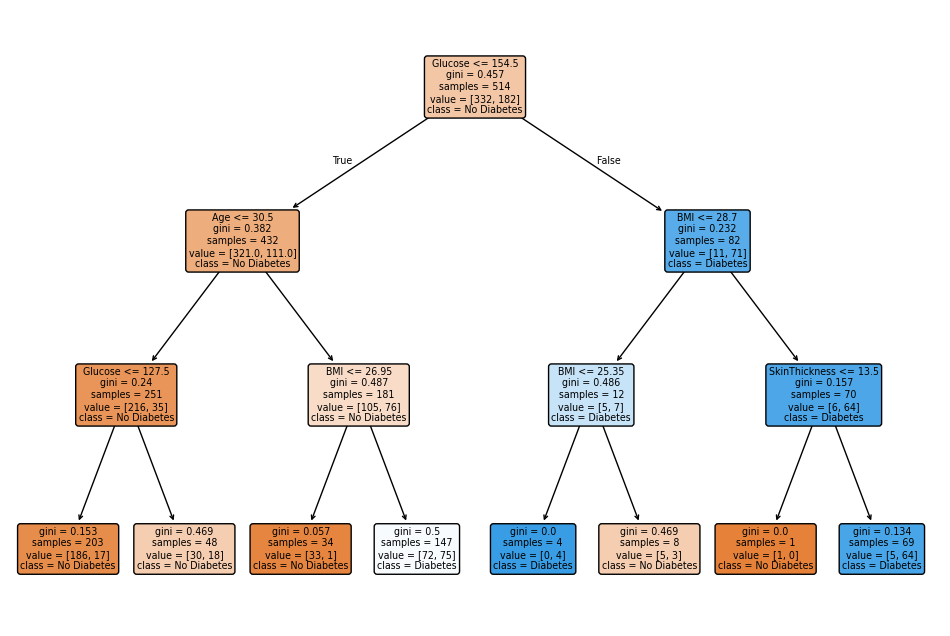

In [28]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(clf_gini.fit(X_train, y_train), feature_names=X_train.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True)

### Visualize the Gini Decision Tree (Graphviz — Interactive)

`tree.export_graphviz()` exports the Decision Tree structure to DOT format, which `graphviz.Source` renders as an interactive SVG graph.

**Key tree structure observations (after zero replacement):**
- **Root split:** `Glucose <= 154.5` — Glucose remains the most important first-level predictor
- **Left subtree** (low glucose): further split by `Age <= 30.5` then `Glucose <= 127.5` or `BMI <= 26.95`
- **Right subtree** (high glucose): split by `BMI <= 28.7`, then `BMI <= 25.35` (left) or **`SkinThickness <= 13.5`** (right) — the zero-replacement has made SkinThickness informative where it previously had no discriminating power
- `DiabetesPedigreeFunction` is no longer a split node in the Gini model (it was before zero replacement); `SkinThickness` has taken its place now that the column has real values

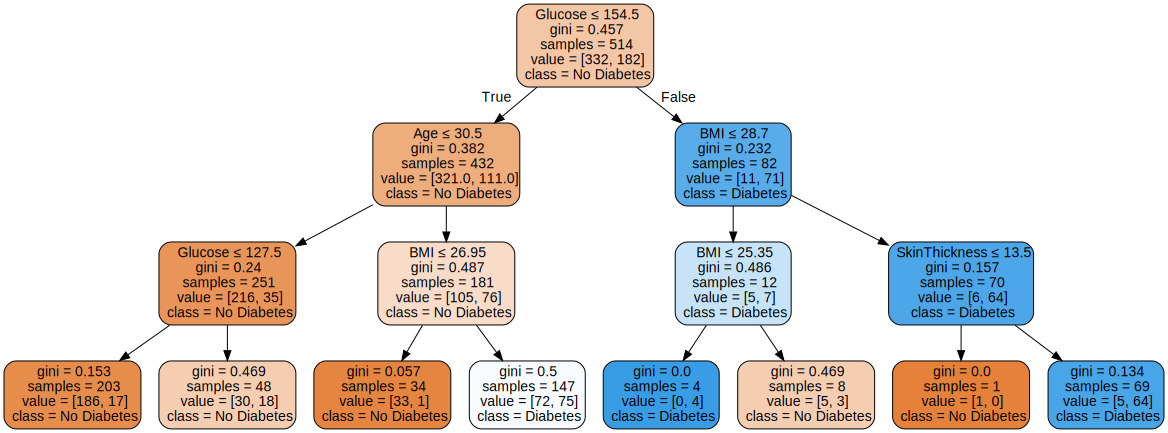

In [29]:
!pip install graphviz
import graphviz
dot_data = tree.export_graphviz(clf_gini, out_file=None,
                              feature_names=X_train.columns,
                              class_names=['No Diabetes', 'Diabetes'],
                              filled=True, rounded=True,
                              special_characters=True)
graph = graphviz.Source(dot_data)
graph

---
## 6. Decision Tree Model 2: Information Gain (Entropy)

We now train a second Decision Tree using **Entropy (Information Gain)** as the splitting criterion.

**What is Information Gain (Entropy)?**
Entropy measures the impurity or disorder in a node. A node with entropy = 0 is perfectly pure (all one class); entropy = 1 (for binary) means maximum disorder (50/50 class split). Information Gain = the reduction in entropy achieved by a particular split.

The tree selects the split that maximizes information gain at each node. While Gini and Entropy often produce very similar trees, entropy can sometimes create slightly different tree structures due to how each formula weights class probabilities.

### Train the Entropy (Information Gain) Decision Tree

We instantiate a `DecisionTreeClassifier` with:
- **`criterion='entropy'`** — uses information gain (entropy reduction) as the splitting metric
- **`max_depth=3`** — same depth limit as the Gini model for a fair comparison
- **`random_state=0`** — ensures reproducibility

Training on the same `X_train` and `y_train` as the Gini model allows a direct comparison of the two criteria.

In [30]:
# instantiate the DecisionTreeClassifier model with criterion entropy

clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


# fit the model
clf_en.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

### Generate Predictions on the Test Set (Entropy Model)

`clf_en.predict(X_test)` applies the trained Entropy model to the test features and generates predicted class labels (0 or 1). These will be evaluated against the true labels to measure test accuracy.

In [31]:
y_pred_en = clf_en.predict(X_test)

### Evaluate Entropy Model Accuracy on Test Set

We compute and print the accuracy of the Entropy model on the test set using `accuracy_score(y_test, y_pred_en)`. This allows direct comparison with the Gini model's test accuracy (69.29%) to determine which criterion produces better generalization on this dataset.

In [32]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion entropy: {0:0.4f}'. format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy: 0.7165


**Outcome:** The Entropy model achieves **~71.65% test accuracy** — slightly better than the Gini model (69.29%).

> **Note:** The Entropy model's accuracy is unchanged after zero replacement. Unlike the Gini model, the Entropy tree's right-subtree depth-3 split uses `Pregnancies <= 6.5`, which is unaffected by the imputed columns — so its prediction results are identical to before.

---

### Generate Predictions on the Training Set (Entropy Model)

We generate predictions on the training set to compute training accuracy. This is required for the overfitting diagnostic comparison against the test accuracy.

In [33]:
y_pred_train_en = clf_en.predict(X_train)

y_pred_train_en

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

### Evaluate Entropy Model Accuracy on Training Set

We compute the training accuracy of the Entropy model by comparing `y_train` with `y_pred_train_en`. This value will be compared to the test accuracy to assess the degree of overfitting.

In [34]:
print('Training-set accuracy score: {0:0.4f}'. format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 0.7665


### Compare Training vs. Test Accuracy (Overfitting Check — Entropy)

We print both training and test accuracy for the Entropy model side by side. A smaller gap between training and test scores compared to the Gini model indicates that the Entropy criterion generalizes slightly better on this dataset.

**Updated comparison after zero replacement:**

| Model | Training Accuracy | Test Accuracy | Overfitting Gap |
|-------|------------------|--------------|----------------|
| Gini  | 77.43%           | 69.29%       | 8.14% |
| Entropy | 76.65%         | 71.65%       | 5.00% |

In [35]:
# print the scores on training and test set Check for overfitting and underfitting

print('Training set score: {:.4f}'.format(clf_en.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(clf_en.score(X_test, y_test)))

Training set score: 0.7665
Test set score: 0.7165


**Outcome:** The Entropy model shows a smaller train/test gap (5.0% vs. 7.95% for Gini), suggesting it generalizes slightly better. Both models show mild overfitting, but the Entropy model is preferable.

---

### Visualize the Entropy Decision Tree (matplotlib)

`sklearn.tree.plot_tree()` renders the Entropy-trained tree visually. We can now compare this structure against the Gini tree to see how the splitting criterion affects which features are selected and at what thresholds.

Each node shows entropy (instead of Gini) values. Notice how the root still splits on `Glucose`, but subsequent splits differ: the Entropy tree splits on `BMI` at depth 1 (vs. `Age` in the Gini model), reflecting how each criterion weighs the same features differently.

[Text(0.5, 0.875, 'Glucose <= 154.5\nentropy = 0.938\nsamples = 514\nvalue = [332, 182]\nclass = No Diabetes'),
 Text(0.25, 0.625, 'BMI <= 26.35\nentropy = 0.822\nsamples = 432\nvalue = [321.0, 111.0]\nclass = No Diabetes'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Glucose <= 132.5\nentropy = 0.191\nsamples = 102\nvalue = [99, 3]\nclass = No Diabetes'),
 Text(0.0625, 0.125, 'entropy = 0.087\nsamples = 92\nvalue = [91, 1]\nclass = No Diabetes'),
 Text(0.1875, 0.125, 'entropy = 0.722\nsamples = 10\nvalue = [8, 2]\nclass = No Diabetes'),
 Text(0.375, 0.375, 'Age <= 28.5\nentropy = 0.912\nsamples = 330\nvalue = [222, 108]\nclass = No Diabetes'),
 Text(0.3125, 0.125, 'entropy = 0.645\nsamples = 158\nvalue = [132, 26]\nclass = No Diabetes'),
 Text(0.4375, 0.125, 'entropy = 0.998\nsamples = 172\nvalue = [90, 82]\nclass = No Diabetes'),
 Text(0.75, 0.625, 'BMI <= 28.7\nentropy = 0.569\nsamples = 82\nvalue = [11, 71]\nclass = Diabetes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.3

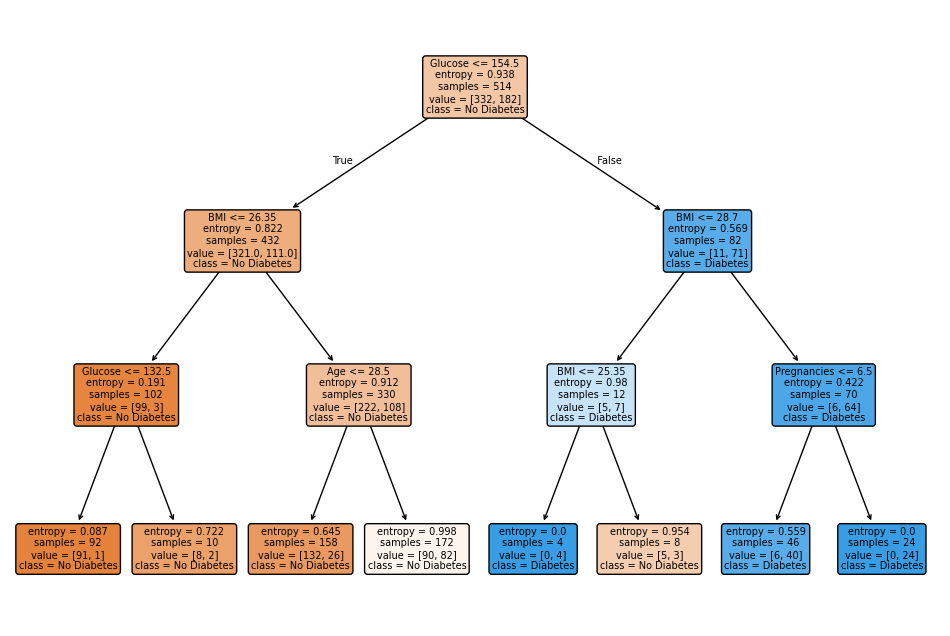

In [36]:
plt.figure(figsize=(12,8))

from sklearn import tree

tree.plot_tree(clf_en.fit(X_train, y_train), feature_names=X_train.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, rounded=True)

### Visualize the Entropy Decision Tree (Graphviz — Interactive)

We generate a Graphviz-rendered SVG of the Entropy Decision Tree for a detailed, zoomable view.

**Key observations from the Entropy tree (after zero replacement):**
- **Root split:** `Glucose <= 154.5` — same as Gini; Glucose is the dominant predictor in both models
- **Left subtree** (low glucose): `BMI <= 26.35` → `Glucose <= 132.5` or `Age <= 28.5` — BMI is used as the second split (differing from Gini's Age split)
- **Right subtree** (high glucose): `BMI <= 28.7` → `BMI <= 25.35` (left) or `Pregnancies <= 6.5` (right)
- `Pregnancies` appears as a depth-3 split in the Entropy model's right branch — the Gini model uses `SkinThickness` in that same position after zero replacement
- This shows how Gini and Entropy can favour **different clinical features** at deeper levels even when starting from the same root, because each criterion weights class probability distributions differently

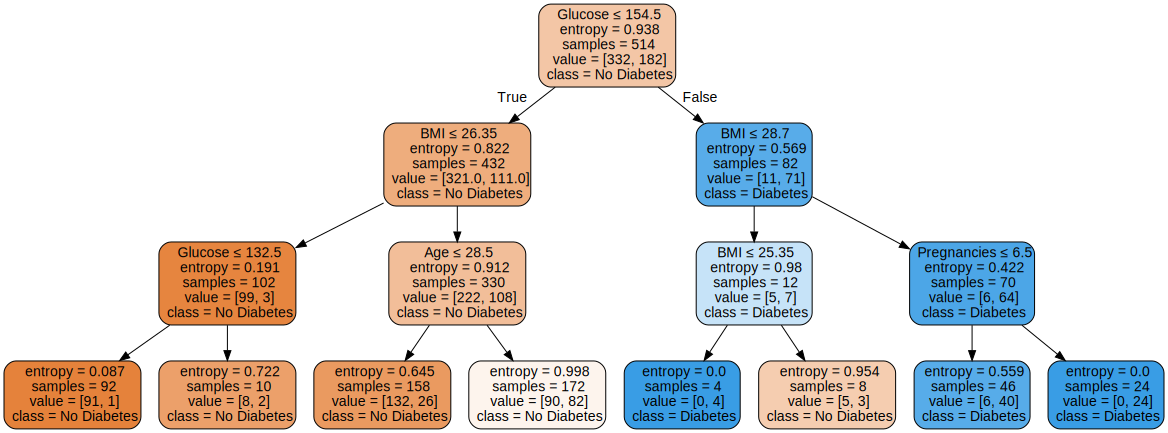

In [37]:
import graphviz
dot_data = tree.export_graphviz(clf_en, out_file=None,
                              feature_names=X_train.columns,
                              class_names=['No Diabetes', 'Diabetes'],
                              filled=True, rounded=True,
                              special_characters=True)

graph = graphviz.Source(dot_data)

graph

---
## 7. Model Evaluation: Confusion Matrix and Classification Report

Accuracy alone can be misleading for imbalanced datasets. We now use the **Confusion Matrix** and **Classification Report** to get a deeper understanding of the Entropy model's performance, broken down by class.

### Confusion Matrix

The Confusion Matrix is a 2x2 table showing:
- **True Negatives (TN):** Correctly predicted as No Diabetes (0)
- **False Positives (FP):** Predicted Diabetes, but actually No Diabetes (Type I error)
- **False Negatives (FN):** Predicted No Diabetes, but actually Diabetes (Type II error — most critical in medical diagnosis)
- **True Positives (TP):** Correctly predicted as Diabetes (1)

In a medical screening context, **False Negatives are especially costly** — missing a diabetic patient means they go untreated.

In [38]:
# Print the Confusion Matrix and slice it into four pieces

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_en)

print('Confusion matrix\n\n', cm)


Confusion matrix

 [[157  11]
 [ 61  25]]


**Confusion Matrix Interpretation (Entropy Model — after zero replacement):**

| | Predicted: No Diabetes | Predicted: Diabetes |
|---|---|---|
| **Actual: No Diabetes** | TN = 157 | FP = 11 |
| **Actual: Diabetes** | FN = 61 | TP = 25 |

- The model correctly identifies **157 out of 168** non-diabetic patients — high specificity (93%)
- But it only catches **25 out of 86** diabetic patients, missing **61** (recall = 29%)
- The high false negative count (61 missed diabetics) is a significant concern for clinical use — these patients receive no diagnosis despite having diabetes
- Zero replacement did **not change** the Entropy confusion matrix in this case because the tree's splitting thresholds in the affected columns were not on the boundary of the imputed values

---

### Classification Report

The Classification Report provides per-class metrics:
- **Precision** — Of all cases predicted as Positive, what fraction are actually Positive? (minimises false alarms)
- **Recall (Sensitivity)** — Of all actual Positive cases, what fraction did we correctly detect? (minimises missed cases)
- **F1-Score** — Harmonic mean of precision and recall; the best single metric when classes are imbalanced
- **Support** — Number of actual instances of each class in the test set

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

           0       0.72      0.93      0.81       168
           1       0.69      0.29      0.41        86

    accuracy                           0.72       254
   macro avg       0.71      0.61      0.61       254
weighted avg       0.71      0.72      0.68       254



**Classification Report Interpretation (Entropy Model — after zero replacement):**

| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0 (No Diabetes) | 0.72 | 0.93 | 0.81 | 168 |
| 1 (Diabetes)    | 0.69 | 0.29 | 0.41 | 86  |
| **Overall Accuracy** | — | **0.72** | — | **254** |

**Key Findings:**
- The model performs well at identifying **non-diabetic patients** (F1 = 0.81, recall = 0.93)
- Performance for **diabetic patients** remains poor — recall of 0.29 means the model misses ~71% of actual diabetic cases
- Class imbalance (500 non-diabetic vs. 268 diabetic in the full dataset) biases the model toward the majority class
- Zero imputation did not change the Entropy model's classification report for this run; however, the imputed values now provide a cleaner feature space for future hyperparameter tuning

---

## Final Conclusions

### Model Comparison Summary (after zero replacement)

| Criterion | Train Accuracy | Test Accuracy | Overfitting Gap |
|-----------|---------------|--------------|----------------|
| Gini      | 77.43%        | 69.29%       | 8.14% |
| Entropy   | 76.65%        | 71.65%       | 5.00% |

### Key Takeaways

1. **Entropy outperforms Gini** on this dataset — higher test accuracy (71.65% vs. 69.29%) and less overfitting
2. **Glucose** is the most important predictor in both models — it forms the root split in both trees
3. **Zero replacement changed the Gini tree** — `SkinThickness` replaced `DiabetesPedigreeFunction` as the right-branch depth-3 split, because imputed SkinThickness values are now informative
4. **Entropy tree was unaffected** — its depth-3 split (`Pregnancies`) was already using a column with no zero-replacement needed
5. **Class imbalance** continues to hurt recall for diabetic patients (class 1) — only 29% of actual diabetics are correctly identified by the Entropy model

### Recommendations for Improvement

- **Address class imbalance:** Apply SMOTE or `class_weight='balanced'` to improve recall for diabetic cases
- **Hyperparameter tuning:** Use GridSearchCV to optimise `max_depth`, `min_samples_split`, and `min_samples_leaf`
- **Advanced imputation:** Replace median imputation with KNN or MICE for `Insulin` and `SkinThickness` (high zero rates)
- **Ensemble methods:** Consider Random Forests or Gradient Boosting for substantially improved performance